## Phase 3: Supervised Classification

**Objective:** To identify NCAA Cinderella teams using a two step pipeline. First, we generated an unsupervised `Isolation_Score` to find statistical anomalies. Second we feed that score into supervised classifiers (Random Forest and XGBoost) to predict tournament over-performers.

### 0. Setup

In [24]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [25]:
# Keep all imports at the very top of the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, average_precision_score, recall_score
from xgboost import XGBClassifier
import shap

### 1. Data Loading and Feature Selection

Load the pre-processed metrics from the EDA phase and isolate the regular-season stats from the target variables. Create a `CinderellaFlag` variable in the data set.

In [32]:
# Load Data
# Note: Update this path if your metrics.csv is located elsewhere in your data folder
df = pd.read_csv('../data/metrics.csv') 

# Drop rows missing critical features
df = df.dropna(subset=['SeedNum', 'AvgScoreDiff', 'MasseyRankMean'])

# Create the Target Variable: Cinderellas are Seed 10+ and reached the Sweet 16 (2+ wins)
df['CinderellaFlag'] = ((df['SeedNum'] >= 10) & (df['TourneyWins'] >= 2)).astype(int)

# Define initial base features and target
base_features = ['SeedNum', 'AvgScoreDiff', 'WinPct', 'MasseyRankMean', 'AvgPointsFor', 'AvgPointsAgainst']
X = df[base_features].copy()
y = df['CinderellaFlag']

print(f"Data loaded successfully. Shape: {df.shape}")
print(f"Cinderellas found: {y.sum()} out of {len(y)} ({round(y.sum()/len(y)*100, 2)}%)")

Data loaded successfully. Shape: (1472, 35)
Cinderellas found: 53 out of 1472 (3.6%)


### 2. Train/Test Split & CV Setup

Due to the extreme class imbalance (Cinderellas makes up <1% of the data), we use `StratifiedKFold` cross-validation to ensure the minority class is evently distributed across folds. Standard accuracy is discarded because of the class imbalance in favor of Precision-Recall AUC and F1-Score.

In [33]:
# Train/Test Split (Stratified to maintain the extreme 0.64% class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Cross-Validation Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom scoring metrics (Accuracy is ignored due to class imbalance)
scoring = {
    'F1': make_scorer(f1_score), 
    'PR_AUC': make_scorer(average_precision_score), 
    'Recall': make_scorer(recall_score)
}

print(f"Training set shape: {X_train.shape}")
print(f"Cinderellas in training set: {sum(y_train)}")

Training set shape: (1177, 6)
Cinderellas in training set: 42


### 3. Unsupervised Anomaly Detection

Before running our classifiers, we need to generate our novel feature. We use an Isolation Forest trained only on regular-season performance stats (ignoring seeds and rankings) to identify teams with highly unusual statistical profiles. High negative scores indicate a strong anomaly *(I know this is done for part 4, but it is what we said we would do)*.

In [34]:
print("Generating Unsupervised Anomaly Scores...")

# We use only regular season performance stats (no seeds or rankings) to find statistical anomalies
stats_for_anomaly = ['AvgScoreDiff', 'WinPct', 'AvgPointsFor', 'AvgPointsAgainst']

# Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# FIT ONLY ON TRAINING DATA to prevent leakage
iso_forest.fit(X_train[stats_for_anomaly])

# Transform both Train and Test sets
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Isolation_Score'] = iso_forest.decision_function(X_train[stats_for_anomaly])
X_test['Isolation_Score'] = iso_forest.decision_function(X_test[stats_for_anomaly])

# Update our feature list to include this new unsupervised feature for Phase 2
features = base_features + ['Isolation_Score']

print("Phase 1 Complete: 'Isolation_Score' successfully added to the feature set.")

Generating Unsupervised Anomaly Scores...
Phase 1 Complete: 'Isolation_Score' successfully added to the feature set.


### 4. Baseline Model: Random Forest

We begin with a Random Forest classifier to establish a baseline for how tree-based model handle the engineered anomaly scores alongside traditional seeding.

In [35]:
print("Training Random Forest Baseline...\n")

# Build the pipeline
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Define hyperparameters to search
rf_param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [5, 10]
}

# Run Grid Search
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring=scoring, refit='PR_AUC')
rf_grid.fit(X_train, y_train)

# Output results
print("Best RF Params:", rf_grid.best_params_)
print("RF Cross-Val PR-AUC:", round(rf_grid.cv_results_['mean_test_PR_AUC'][rf_grid.best_index_], 4))
print("RF Cross-Val F1:", round(rf_grid.cv_results_['mean_test_F1'][rf_grid.best_index_], 4))
print("RF Cross-Val Recall:", round(rf_grid.cv_results_['mean_test_Recall'][rf_grid.best_index_], 4))

Training Random Forest Baseline...

Best RF Params: {'rf__max_depth': 5, 'rf__n_estimators': 100}
RF Cross-Val PR-AUC: 0.1266
RF Cross-Val F1: 0.2616
RF Cross-Val Recall: 0.5583


### 5. Advanced Model: XGBoost

XGBoost provides finer control over the extreme class imbalance via the `scale_pos_weight` parameter. We tune this alongside  learning rate and tree depth to maximize precision and recall.

In [36]:
print("Training Advanced XGBoost Model...\n")

# Build the pipeline
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Calculate a dynamic weight for the minority class
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Define hyperparameters to search
xgb_param_grid = {
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__scale_pos_weight': [weight * 0.5, weight, weight * 1.5] 
}

# Run Grid Search
xgb_grid = GridSearchCV(xgb_pipe, xgb_param_grid, cv=cv, scoring=scoring, refit='PR_AUC')
xgb_grid.fit(X_train, y_train)

# Output results
print("Best XGB Params:", xgb_grid.best_params_)
print("XGB Cross-Val PR-AUC:", round(xgb_grid.cv_results_['mean_test_PR_AUC'][xgb_grid.best_index_], 4))
print("XGB Cross-Val F1:", round(xgb_grid.cv_results_['mean_test_F1'][xgb_grid.best_index_], 4))
print("XGB Cross-Val Recall:", round(xgb_grid.cv_results_['mean_test_Recall'][xgb_grid.best_index_], 4))

Training Advanced XGBoost Model...

Best XGB Params: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__scale_pos_weight': 13.511904761904763}
XGB Cross-Val PR-AUC: 0.1611
XGB Cross-Val F1: 0.2947
XGB Cross-Val Recall: 0.6528


### 6. Model Explainability (SHAP)

To understand how the XGBoost model is making its predictions, we utilize SHapley Additive exPlanations (SHAP). This summary plot shows the directional impact of each feature on the model's output.

Generating SHAP summary plot...


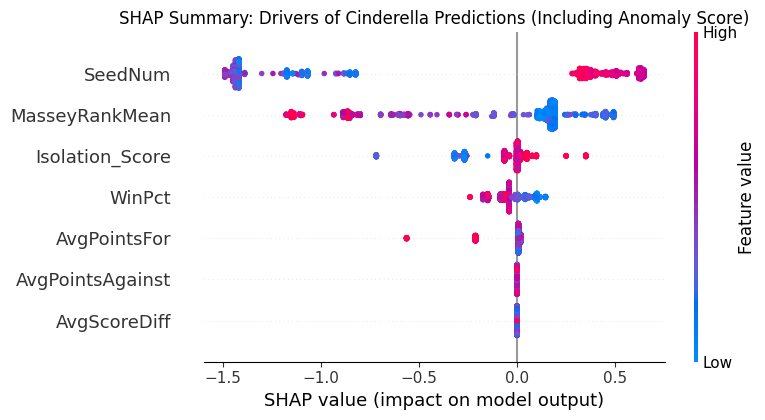

In [37]:
print("Generating SHAP summary plot...")

# Extract the trained model and scaler from the best XGBoost pipeline
best_xgb = xgb_grid.best_estimator_.named_steps['xgb']
scaler = xgb_grid.best_estimator_.named_steps['scaler']

# Scale the training data so SHAP can interpret it correctly
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=features)

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train_scaled)

# Plot the summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_scaled, show=False)

# Formatting and saving
plt.title("SHAP Summary: Drivers of Cinderella Predictions (Including Anomaly Score)")
plt.tight_layout()

# Make sure the 'assets' folder exists in your directory tree
import os
os.makedirs('../assets', exist_ok=True)
plt.savefig('../assets/shap_summary.png', dpi=300, bbox_inches='tight')

plt.show()